# 02 — Feature Engineering Comportemental
## BAMIS Fraud Detection | DATATHON ESP DATACLUB 2026

Construction des **18 variables comportementales** pour le pipeline de détection de fraude.

### Architecture
```
DATASET_ESP-2026.csv
        ↓
preprocessing.py  →  DataFrame nettoyé
        ↓
feature_engineering.py  →  18 features
        ↓
[Isolation Forest | Rule Engine | Graph Engine]
```

### Groupes de features
| # | Groupe | Features | Signal fraude |
|---|---|---|---|
| 1 | Temporel | tx_hour, tx_is_night, tx_is_weekend | Activité nocturne/week-end |
| 2 | Rolling | roll_count/amount × 3 fenêtres | Pic de volume |
| 3 | Vélocité | seconds_since_last_tx | Transactions en rafale |
| 4 | Seuil | is_near_threshold × 3, is_potential_split | Fractionnement |
| 5 | Frais | fee_ratio | Frais aberrants / nuls |
| 6 | Fan-out | unique_dest_7d | Compte mule |


In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────
import sys, warnings, os, random
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.data.preprocessing import (
    _build_normalized_csv, _parse_dates, _parse_numerics,
    _clean_strings, _validate, _normalize_amounts,
    COLUMNS_EXPECTED, data_quality_report,
)
from src.features.feature_engineering import (
    build_features,
    add_temporal_features,
    add_rolling_features,
    add_velocity_features,
    add_threshold_features,
    add_fee_ratio_feature,
    add_counterparty_features,
    THRESHOLD_LOW, THRESHOLD_MID, THRESHOLD_HIGH,
)

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

print("✅ Imports OK")
print(f"   pandas {pd.__version__}  |  numpy {np.__version__}")


✅ Imports OK
   pandas 2.3.3  |  numpy 2.2.6


---
## 1. Chargement et Preprocessing

On utilise directement `preprocess()` du module `src.data.preprocessing`.  
Pour les visualisations interactives on travaille sur un **échantillon de 100 000 lignes**.


In [2]:
DATA_PATH = Path('../src/data/DATASET_ESP-2026.csv')
SAMPLE_SIZE = 100_000
SAMPLE_FRAC = SAMPLE_SIZE / 1_627_757  # ~6.1% to get ~100K rows
random.seed(42)

print(f"Taille fichier : {DATA_PATH.stat().st_size / 1e6:.1f} Mo")
print("Normalisation du CSV en cours...")
norm_path = _build_normalized_csv(DATA_PATH)
print(f"CSV normalisé prêt : {norm_path.stat().st_size / 1e6:.1f} Mo")

# Load with sampling to avoid OOM
df_raw = pd.read_csv(
    norm_path,
    dtype=str,
    low_memory=False,
    index_col=False,
    skiprows=lambda i: i > 0 and random.random() > SAMPLE_FRAC,
    encoding='utf-8',
    encoding_errors='replace',
)
df_raw.columns = df_raw.columns.str.strip().str.upper()
norm_path.unlink(missing_ok=True)

print(f"Échantillon chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")

# Apply preprocessing pipeline steps manually
df_full = _parse_dates(df_raw)
df_full = _parse_numerics(df_full)
df_full = _clean_strings(df_full)
df_full = _validate(df_full)
df_full = _normalize_amounts(df_full)

assert list(df_full.columns[:23]) == COLUMNS_EXPECTED, 'Column mismatch!'
print(f"Dataset preprocessé : {df_full.shape[0]:,} lignes × {df_full.shape[1]} colonnes")

# Échantillon reproductible trié chronologiquement
df = (
    df_full
    .sample(n=min(SAMPLE_SIZE, len(df_full)), random_state=42)
    .sort_values('TRANSACTION_DATE')
    .reset_index(drop=True)
)
print(f"Échantillon de travail : {len(df):,} lignes")

report = data_quality_report(df)
print(f"\nPériode : {report['date_range']['min']}  →  {report['date_range']['max']}")
print(f"Codes doublons : {report['duplicate_tx_codes']:,}")


Taille fichier : 385.6 Mo
Normalisation du CSV en cours...


CSV normalisé prêt : 384.0 Mo


Échantillon chargé : 99,924 lignes × 23 colonnes


Dataset preprocessé : 99,924 lignes × 25 colonnes
Échantillon de travail : 99,924 lignes



Période : 2003-06-05 18:38:48.777000  →  2026-07-15 00:18:20.711000
Codes doublons : 0


In [3]:
# Aperçu du dataset nettoyé
print("Colonnes disponibles :", list(df.columns))
df[['TRANSACTION_CODE','TRANSACTION_DATE','TRANSACTION_AMOUNT',
    'SOURCE_PHONE','DESTINATION_PHONE','TRANSACTION_FEES',
    'TRANSACTION_STATUS','SERVICE_CODE']].head(5)


Colonnes disponibles : ['TRANSACTION_CODE', 'SERVICE_CODE', 'TRANSACTION_STATUS', 'TRANSACTION_DATE', 'TRANSACTION_AMOUNT', 'REQUEST_REFERENCE', 'REQUEST_DATE', 'RESPONSE_DATE', 'SOURCE_PHONE', 'DESTINATION_PHONE', 'TRANSACTION_FEES', 'DESTINATION_TYPE', 'PARTNER_REFERENCE', 'BATCH_ID', 'SOURCE_CUSTOMER', 'DESTINATION_CUSTOMER', 'TRANSACTION_DIRECTION', 'QR_INDICATOR', 'ACCOUNTING_RESPONSE_DATE', 'ACCOUNTING_REQUEST_DATE', 'SETTLEMENT_STATUS', 'CHANNEL_TYPE', 'LANGUAGE_CODE', 'TRANSACTION_AMOUNT_NORM', 'TRANSACTION_FEES_NORM']


,TRANSACTION_CODE,TRANSACTION_DATE,TRANSACTION_AMOUNT,SOURCE_PHONE,DESTINATION_PHONE,TRANSACTION_FEES,TRANSACTION_STATUS,SERVICE_CODE
0,40395,2003-06-05 18:38:48.777,200.0,TEL001812,TEL123494,0.0,VALIDATED,SERVICE_06
1,40401,2003-06-05 19:17:58.841,10.0,TEL053873,TEL053873,0.0,VALIDATED,SERVICE_06
2,40420,2003-06-06 01:36:38.886,20.0,TEL051667,TEL031964,0.0,VALIDATED,SERVICE_06
3,40430,2003-06-06 09:15:29.543,100.0,TEL168133,TEL168133,0.0,VALIDATED,SERVICE_06
4,1941,2022-03-24 20:04:39.565,1000.0,TEL137400,TEL140371,10.0,VALIDATED,SERVICE_10


---
## 2. Features Temporelles
> **Hypothèse** : les transactions frauduleuses sont sur-représentées la nuit et le week-end,
> quand les contrôles humains sont absents.


In [4]:
df_t = add_temporal_features(df.copy())

temporal_cols = ['tx_hour','tx_day_of_week','tx_is_weekend','tx_is_night']
print("Colonnes créées :", temporal_cols)
print()
print(df_t[temporal_cols].astype(float).describe().T[['mean','std','min','max']].round(3).to_string())


Colonnes créées : ['tx_hour', 'tx_day_of_week', 'tx_is_weekend', 'tx_is_night']

                  mean    std  min   max
tx_hour         14.418  5.804  0.0  23.0
tx_day_of_week   2.891  1.944  0.0   6.0
tx_is_weekend    0.249  0.432  0.0   1.0
tx_is_night      0.179  0.383  0.0   1.0


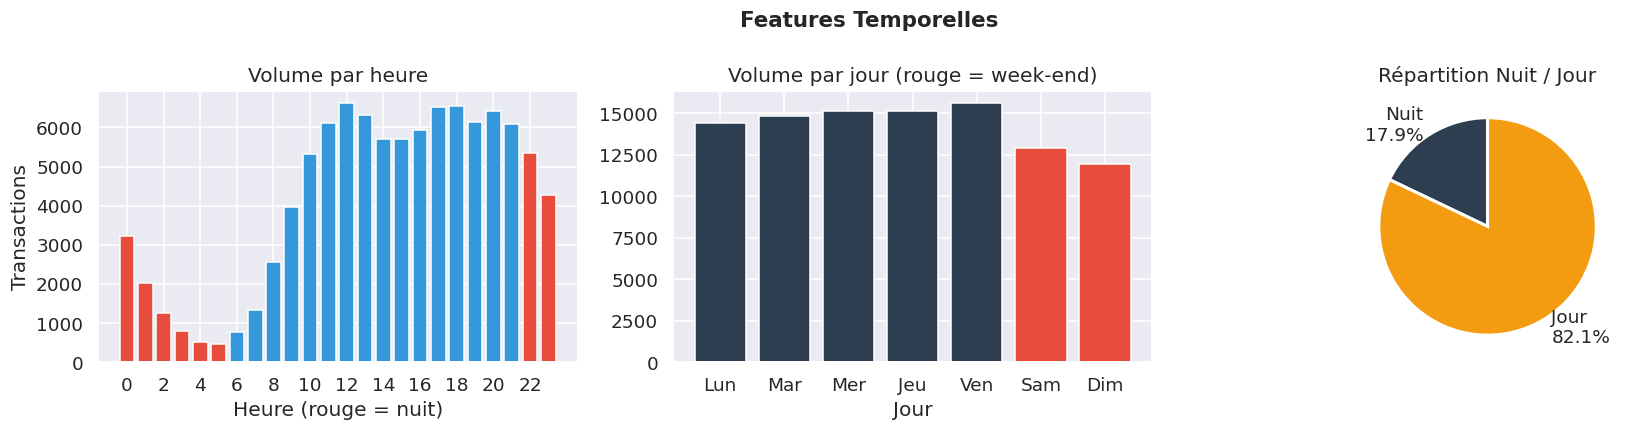

🌙 Nuit : 17.91%  |  📅 Week-end : 24.85%


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Features Temporelles', fontsize=14, fontweight='bold')

# Volume horaire
hour_cnt = df_t['tx_hour'].value_counts().sort_index()
night_colors = ['#e74c3c' if h >= 22 or h < 6 else '#3498db' for h in hour_cnt.index]
axes[0].bar(hour_cnt.index, hour_cnt.values, color=night_colors)
axes[0].set_title('Volume par heure')
axes[0].set_xlabel('Heure (rouge = nuit)')
axes[0].set_ylabel('Transactions')
axes[0].set_xticks(range(0, 24, 2))

# Volume par jour de semaine
day_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
dow_cnt = df_t['tx_day_of_week'].value_counts().sort_index()
bar_colors = ['#e74c3c' if i >= 5 else '#2c3e50' for i in range(7)]
axes[1].bar([day_labels[i] for i in dow_cnt.index],
            dow_cnt.values,
            color=[bar_colors[i] for i in dow_cnt.index])
axes[1].set_title('Volume par jour (rouge = week-end)')
axes[1].set_xlabel('Jour')

# Camembert nuit/jour
night_pct = df_t['tx_is_night'].mean() * 100
axes[2].pie([night_pct, 100-night_pct],
            labels=[f'Nuit\n{night_pct:.1f}%', f'Jour\n{100-night_pct:.1f}%'],
            colors=['#2c3e50','#f39c12'],
            wedgeprops={'edgecolor':'white','linewidth':2}, startangle=90)
axes[2].set_title('Répartition Nuit / Jour')

plt.tight_layout()
plt.savefig('../reports/figures/02_temporal.png', bbox_inches='tight')
plt.show()
print(f"🌙 Nuit : {night_pct:.2f}%  |  📅 Week-end : {df_t['tx_is_weekend'].mean()*100:.2f}%")


---
## 3. Features Rolling (Fenêtres Glissantes)
> **Hypothèse** : un fraudeur génère un pic anormal de transactions sur une courte période.
> Les fenêtres **1h / 24h / 7j** capturent ces accélérations comportementales.


In [6]:
df_r = add_rolling_features(df_t.copy())

roll_cols = [c for c in df_r.columns if c.startswith('roll_')]
print("Colonnes créées :", roll_cols)
print()
print(df_r[roll_cols].describe().T[['mean','std','min','50%','75%','max']].round(2).to_string())


Colonnes créées : ['roll_count_1h', 'roll_amount_1h', 'roll_count_24h', 'roll_amount_24h', 'roll_count_7d', 'roll_amount_7d']

                         mean           std  min     50%     75%           max
roll_count_1h    1.150000e+00  1.000000e+00  1.0     1.0     1.0  2.200000e+01
roll_amount_1h   1.000761e+17  3.163480e+19  0.1   700.0  3500.0  1.000000e+22
roll_count_24h   2.480000e+00  1.239000e+01  1.0     1.0     1.0  2.040000e+02
roll_amount_24h  1.000761e+17  3.163480e+19  1.0   850.0  4000.0  1.000000e+22
roll_count_7d    4.290000e+00  2.669000e+01  1.0     1.0     2.0  5.010000e+02
roll_amount_7d   1.000762e+17  3.163480e+19  1.0  1100.0  5000.0  1.000000e+22


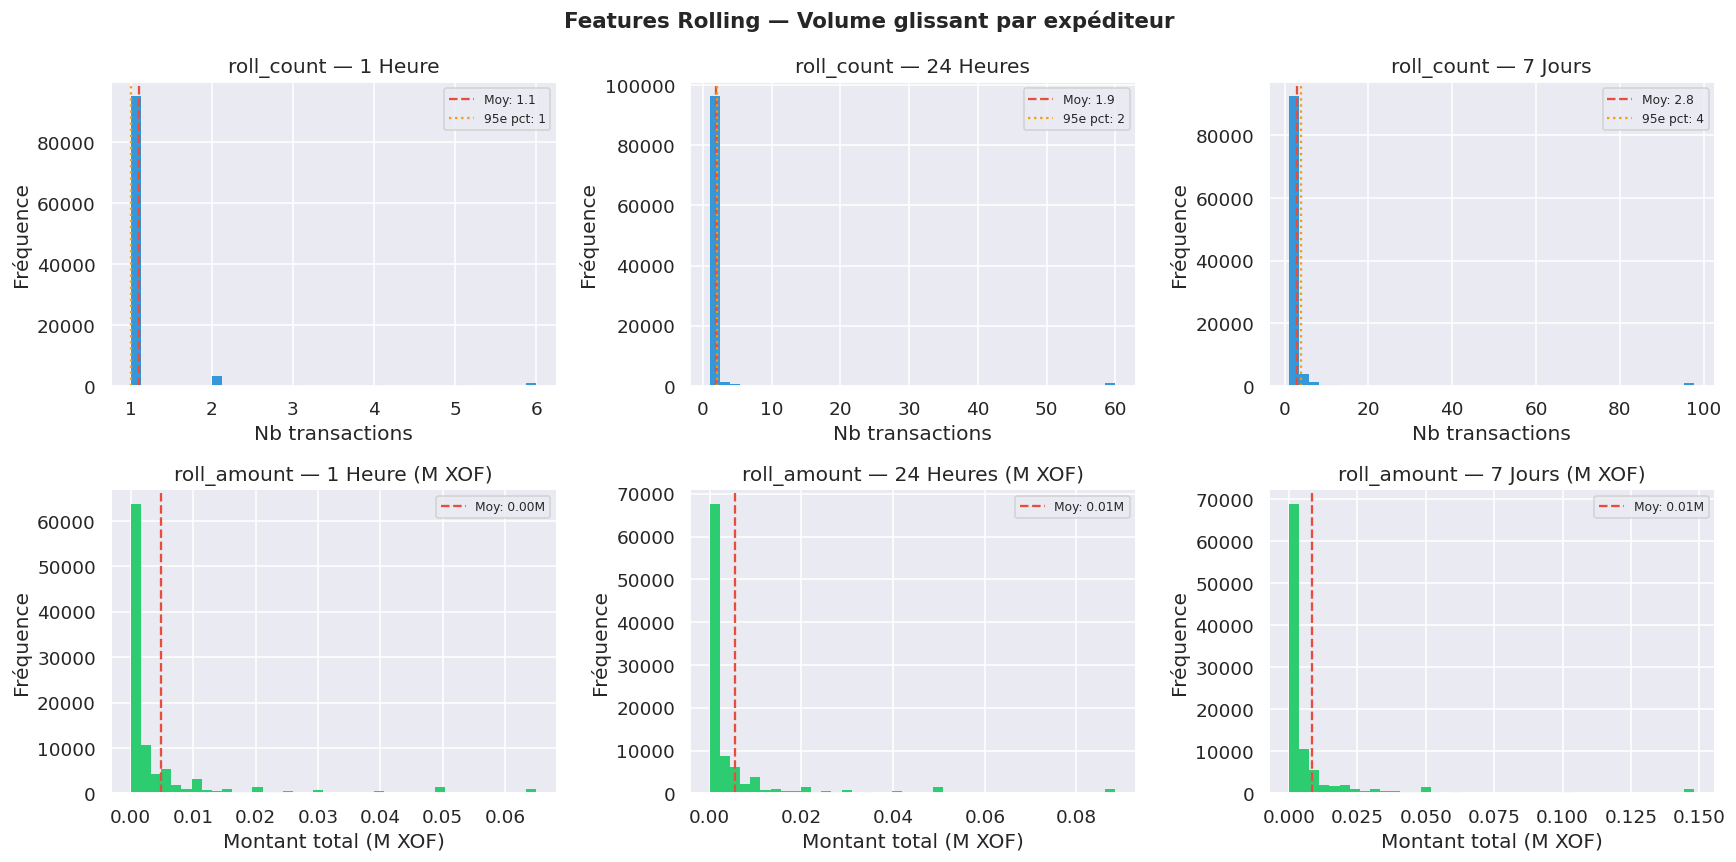

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Features Rolling — Volume glissant par expéditeur', fontsize=14, fontweight='bold')

windows = [
    ('roll_count_1h',   'roll_amount_1h',   '1 Heure'),
    ('roll_count_24h',  'roll_amount_24h',  '24 Heures'),
    ('roll_count_7d',   'roll_amount_7d',   '7 Jours'),
]

for col_idx, (cnt_col, amt_col, label) in enumerate(windows):
    # Count
    data_cnt = df_r[cnt_col].clip(upper=df_r[cnt_col].quantile(0.99))
    axes[0, col_idx].hist(data_cnt, bins=40, color='#3498db', edgecolor='none')
    axes[0, col_idx].axvline(data_cnt.mean(), color='#e74c3c', linestyle='--', linewidth=1.5,
                              label=f'Moy: {data_cnt.mean():.1f}')
    axes[0, col_idx].axvline(data_cnt.quantile(0.95), color='#f39c12', linestyle=':', linewidth=1.5,
                              label=f'95e pct: {data_cnt.quantile(0.95):.0f}')
    axes[0, col_idx].set_title(f'roll_count — {label}')
    axes[0, col_idx].set_xlabel('Nb transactions')
    axes[0, col_idx].set_ylabel('Fréquence')
    axes[0, col_idx].legend(fontsize=8)

    # Amount
    data_amt = (df_r[amt_col] / 1e6).clip(upper=(df_r[amt_col] / 1e6).quantile(0.99))
    axes[1, col_idx].hist(data_amt, bins=40, color='#2ecc71', edgecolor='none')
    axes[1, col_idx].axvline(data_amt.mean(), color='#e74c3c', linestyle='--', linewidth=1.5,
                              label=f'Moy: {data_amt.mean():.2f}M')
    axes[1, col_idx].set_title(f'roll_amount — {label} (M XOF)')
    axes[1, col_idx].set_xlabel('Montant total (M XOF)')
    axes[1, col_idx].set_ylabel('Fréquence')
    axes[1, col_idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/02_rolling.png', bbox_inches='tight')
plt.show()


In [8]:
# Top transactions avec roll_count_1h élevé (signaux suspects)
top_rapid = df_r.nlargest(10, 'roll_count_1h')[
    ['SOURCE_PHONE','TRANSACTION_DATE','TRANSACTION_AMOUNT',
     'roll_count_1h','roll_amount_1h']
].reset_index(drop=True)
print("Top 10 — Expéditeurs avec le plus fort roll_count_1h :")
print(top_rapid.to_string(index=False))


Top 10 — Expéditeurs avec le plus fort roll_count_1h :
SOURCE_PHONE        TRANSACTION_DATE  TRANSACTION_AMOUNT  roll_count_1h  roll_amount_1h
   TEL080205 2022-12-27 12:24:06.630                 1.0           22.0            22.0
   TEL080205 2022-12-27 12:26:01.800                 1.0           22.0            22.0
   TEL080205 2022-12-27 12:23:51.007                 1.0           21.0            21.0
   TEL080205 2022-12-27 12:21:03.235                 1.0           20.0            20.0
   TEL080205 2022-12-27 12:36:22.971                 1.0           20.0            20.0
   TEL080205 2022-12-27 12:18:10.515                 1.0           19.0            19.0
   TEL080205 2022-12-27 12:20:32.484                 1.0           19.0            19.0
   TEL080205 2022-12-27 12:53:07.912                 1.0           19.0            19.0
   TEL080205 2022-12-27 12:14:09.586                 1.0           18.0            18.0
   TEL080205 2022-12-27 12:16:44.402                 1.0         

---
## 4. Vélocité Transactionnelle
> **seconds_since_last_tx** : temps écoulé depuis la transaction précédente du même expéditeur.  
> Une valeur très faible (< 60s) est un signal d'alarme fort.


In [9]:
df_v = add_velocity_features(df_r.copy())
vel = df_v['seconds_since_last_tx'].dropna()

print(f"Transactions avec un précédent : {len(vel):,}  ({len(vel)/len(df_v)*100:.1f}%)")
print()
print("Statistiques (secondes) :")
print(f"  Min            : {vel.min():>10.0f}s")
print(f"  Médiane        : {vel.median():>10.0f}s  ({vel.median()/3600:.1f}h)")
print(f"  Moyenne        : {vel.mean():>10.0f}s")
print(f"  Max            : {vel.max():>10.0f}s  ({vel.max()/86400:.1f} jours)")
print(f"\n  < 60s   (très rapide) : {(vel < 60).sum():>7,}  ({(vel < 60).mean()*100:.2f}%)")
print(f"  < 5min                : {(vel < 300).sum():>7,}  ({(vel < 300).mean()*100:.2f}%)")
print(f"  < 1h                  : {(vel < 3600).sum():>7,}  ({(vel < 3600).mean()*100:.2f}%)")


Transactions avec un précédent : 83,483  (83.5%)

Statistiques (secondes) :
  Min            :          0s


  Médiane        :    1041479s  (289.3h)
  Moyenne        :    3546991s
  Max            :  619877203s  (7174.5 jours)

  < 60s   (très rapide) :     923  (1.11%)
  < 5min                :   2,558  (3.06%)
  < 1h                  :   4,975  (5.96%)


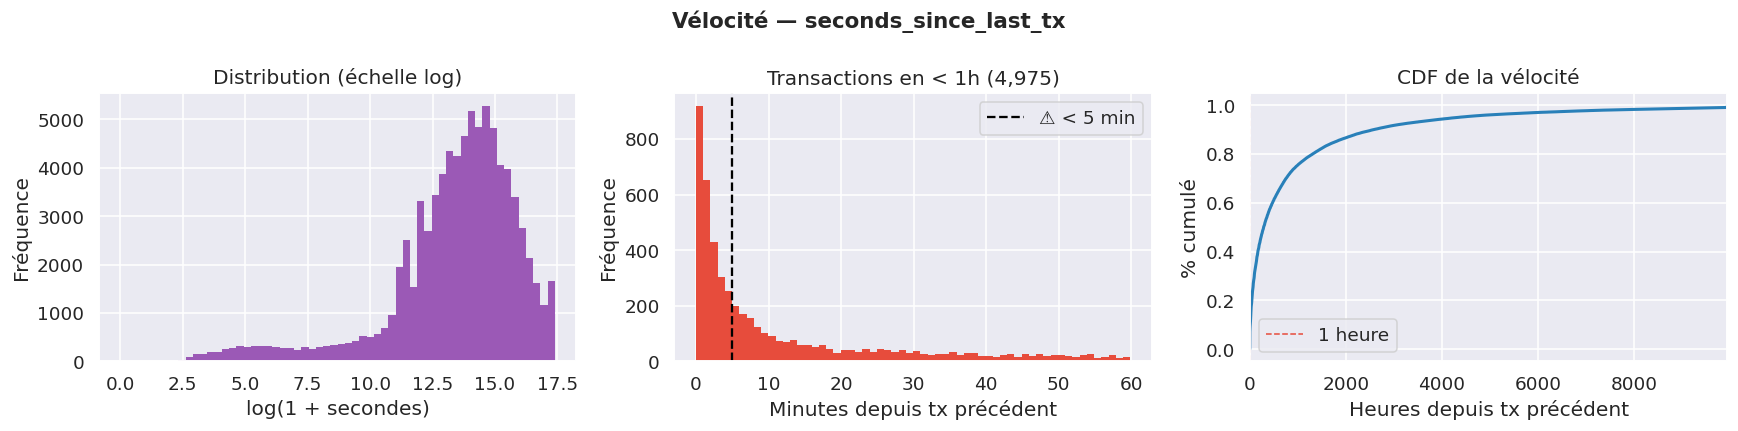

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Vélocité — seconds_since_last_tx', fontsize=14, fontweight='bold')

# Distribution log
axes[0].hist(np.log1p(vel.clip(upper=vel.quantile(0.99))), bins=60,
             color='#9b59b6', edgecolor='none')
axes[0].set_title('Distribution (échelle log)')
axes[0].set_xlabel('log(1 + secondes)')
axes[0].set_ylabel('Fréquence')

# Zoom < 1h
vel_1h = vel[vel <= 3600]
axes[1].hist(vel_1h / 60, bins=60, color='#e74c3c', edgecolor='none')
axes[1].axvline(5, color='black', linestyle='--', linewidth=1.5,
                label='⚠️ < 5 min')
axes[1].set_title(f'Transactions en < 1h ({len(vel_1h):,})')
axes[1].set_xlabel('Minutes depuis tx précédent')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

# CDF
sorted_vel = np.sort(vel.clip(upper=vel.quantile(0.99)).values)
cdf = np.arange(1, len(sorted_vel)+1) / len(sorted_vel)
axes[2].plot(sorted_vel / 3600, cdf, color='#2980b9', linewidth=2)
axes[2].axvline(1, color='#e74c3c', linestyle='--', linewidth=1, label='1 heure')
axes[2].set_title('CDF de la vélocité')
axes[2].set_xlabel('Heures depuis tx précédent')
axes[2].set_ylabel('% cumulé')
axes[2].legend()
axes[2].set_xlim(0, sorted_vel[-1]/3600)

plt.tight_layout()
plt.savefig('../reports/figures/02_velocity.png', bbox_inches='tight')
plt.show()


---
## 5. Features de Seuil — Détection de Fractionnement
> Un fraudeur fractionne intentionnellement des montants élevés en plusieurs transferts
> juste **en dessous** du seuil de contrôle pour éviter la détection.


In [11]:
df_th = add_threshold_features(df_v.copy())

threshold_cols = [c for c in df_th.columns if 'threshold' in c or 'split' in c or 'exceeds' in c]
print("Colonnes créées :", threshold_cols)
print()
for col in threshold_cols:
    n = df_th[col].sum()
    pct = df_th[col].mean() * 100
    print(f"  {col:<40} {n:>7,}  ({pct:.3f}%)")


Colonnes créées : ['is_near_threshold_low', 'is_near_threshold_mid', 'is_near_threshold_high', 'is_potential_split', 'exceeds_high_threshold']

  is_near_threshold_low                         93  (0.093%)
  is_near_threshold_mid                         10  (0.010%)
  is_near_threshold_high                         2  (0.002%)
  is_potential_split                           105  (0.105%)
  exceeds_high_threshold                         5  (0.005%)


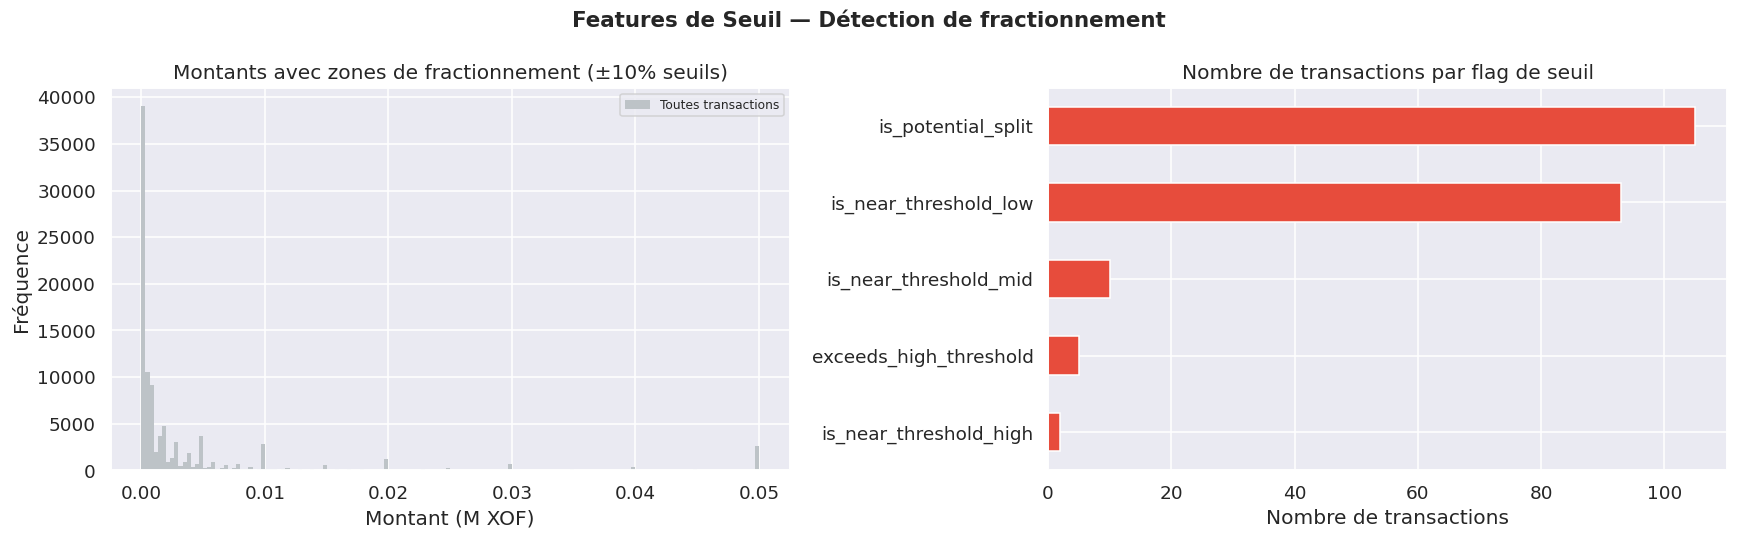

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Features de Seuil — Détection de fractionnement', fontsize=14, fontweight='bold')

# Distribution des montants avec zones de seuil
amounts = df_th['TRANSACTION_AMOUNT'].dropna()
amounts_m = amounts / 1e6
clip_high = amounts_m.quantile(0.98)

axes[0].hist(amounts_m.clip(upper=clip_high), bins=150, color='#bdc3c7', edgecolor='none',
             label='Toutes transactions')
for thresh, label, color in [
    (THRESHOLD_LOW/1e6,  '0.1M XOF', '#3498db'),
    (THRESHOLD_MID/1e6,  '0.5M XOF', '#e67e22'),
    (THRESHOLD_HIGH/1e6, '1.0M XOF', '#e74c3c'),
]:
    if thresh <= clip_high:
        axes[0].axvspan(thresh * 0.9, thresh, alpha=0.3, color=color,
                        label=f'Zone split {label}')
        axes[0].axvline(thresh, color=color, linestyle='--', linewidth=1.5)
axes[0].set_title('Montants avec zones de fractionnement (±10% seuils)')
axes[0].set_xlabel('Montant (M XOF)')
axes[0].set_ylabel('Fréquence')
axes[0].legend(fontsize=8)

# Proportion par flag
flag_counts = df_th[threshold_cols].sum().sort_values(ascending=True)
colors_bar = ['#27ae60' if 'not' not in c else '#e74c3c' for c in flag_counts.index]
flag_counts.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Nombre de transactions par flag de seuil')
axes[1].set_xlabel('Nombre de transactions')

plt.tight_layout()
plt.savefig('../reports/figures/02_threshold.png', bbox_inches='tight')
plt.show()


---
## 6. Ratio de Frais (fee_ratio)
> `fee_ratio = TRANSACTION_FEES / TRANSACTION_AMOUNT`  
> - **= 0** sur un montant élevé → transaction interne suspecte ou manipulation  
> - **> 0.01** (1%) → frais anormalement élevés


In [13]:
df_f = add_fee_ratio_feature(df_th.copy())
fee = df_f['fee_ratio'].dropna()

print("fee_ratio — statistiques :")
print(fee.describe().round(6).to_string())
print(f"\n  fee_ratio == 0.0 : {(fee == 0).sum():>7,}  ({(fee == 0).mean()*100:.2f}%)")
print(f"  fee_ratio > 0.01 : {(fee > 0.01).sum():>7,}  ({(fee > 0.01).mean()*100:.2f}%)")


fee_ratio — statistiques :
count    79711.000000
mean         0.022539
std          0.125803
min          0.000000
25%          0.000000
50%          0.001500
75%          0.010000
max         10.000000

  fee_ratio == 0.0 :  35,405  (44.42%)
  fee_ratio > 0.01 :  18,865  (23.67%)


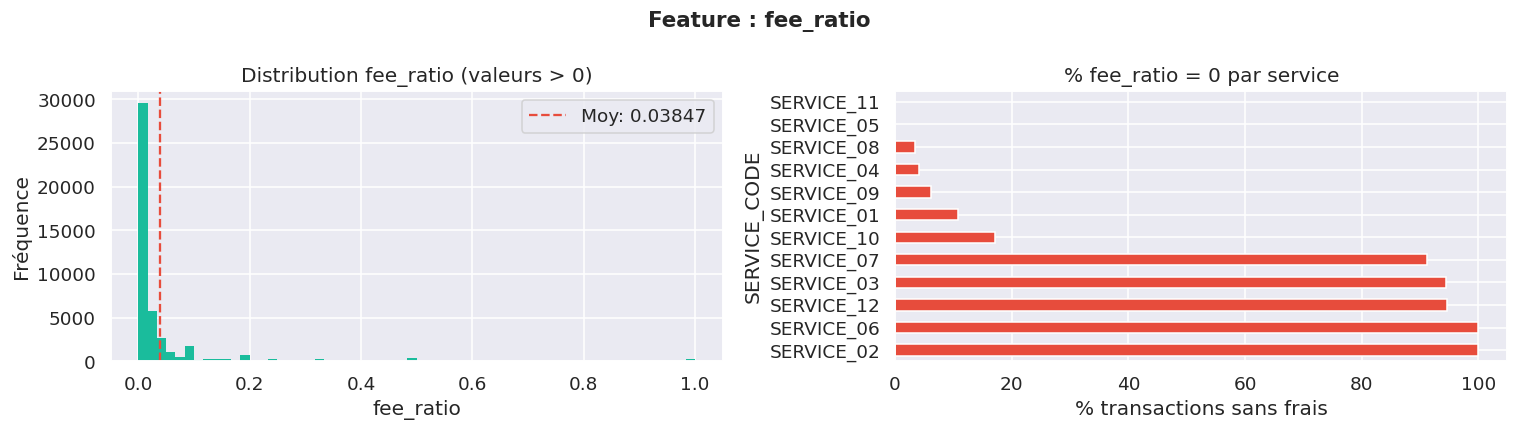

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Feature : fee_ratio', fontsize=14, fontweight='bold')

# Distribution fee > 0
fee_pos = fee[fee > 0].clip(upper=fee[fee > 0].quantile(0.995))
axes[0].hist(fee_pos, bins=60, color='#1abc9c', edgecolor='none')
axes[0].set_title('Distribution fee_ratio (valeurs > 0)')
axes[0].set_xlabel('fee_ratio')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(fee_pos.mean(), color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'Moy: {fee_pos.mean():.5f}')
axes[0].legend()

# % fee_ratio=0 par service
zero_by_svc = (
    df_f.groupby('SERVICE_CODE')['fee_ratio']
    .apply(lambda x: (x == 0).mean() * 100)
    .sort_values(ascending=False)
    .head(12)
)
if len(zero_by_svc):
    zero_by_svc.plot(kind='barh', ax=axes[1], color='#e74c3c')
    axes[1].set_title('% fee_ratio = 0 par service')
    axes[1].set_xlabel('% transactions sans frais')

plt.tight_layout()
plt.savefig('../reports/figures/02_fee_ratio.png', bbox_inches='tight')
plt.show()


---
## 7. Fan-out — Contreparties Uniques (7 jours)
> **`unique_dest_7d`** : nombre de destinataires distincts pour un expéditeur sur 7 jours.  
> Un **fan-out élevé** (1 → many) est la signature classique d'un **compte mule**.


In [15]:
# Calcul sur sous-échantillon (rolling sur strings = calcul intensif)
FANOUT_N = 40_000
print(f"Calcul fan-out sur {FANOUT_N:,} transactions...")
df_cp = add_counterparty_features(df_f.head(FANOUT_N).copy())

dest7 = df_cp['unique_dest_7d'].dropna()
print(f"\nunique_dest_7d — statistiques :")
print(dest7.describe().round(2).to_string())
print(f"\n  > 5 dest. distincts  : {(dest7 > 5).sum():>6,}  ({(dest7 > 5).mean()*100:.2f}%)")
print(f"  > 10 dest. distincts : {(dest7 > 10).sum():>6,}  ({(dest7 > 10).mean()*100:.2f}%)")


Calcul fan-out sur 40,000 transactions...



unique_dest_7d — statistiques :
count    38419.00
mean         1.38
std          1.07
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         15.00

  > 5 dest. distincts  :    514  (1.34%)
  > 10 dest. distincts :     83  (0.22%)


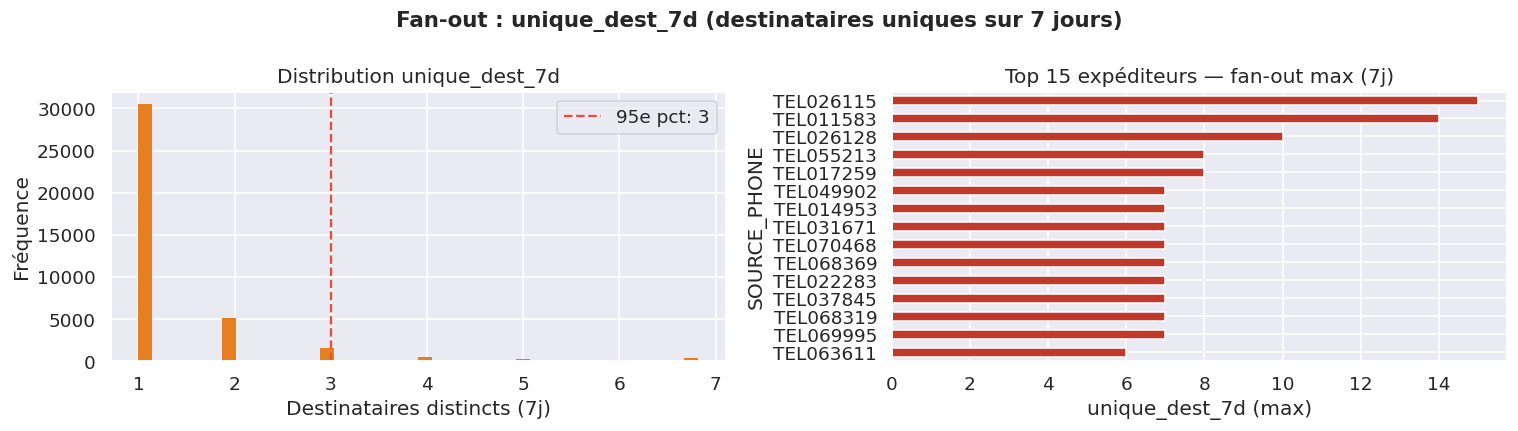

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Fan-out : unique_dest_7d (destinataires uniques sur 7 jours)', fontsize=14, fontweight='bold')

dest_clip = dest7.clip(upper=dest7.quantile(0.99))
axes[0].hist(dest_clip, bins=40, color='#e67e22', edgecolor='none')
axes[0].axvline(dest7.quantile(0.95), color='#e74c3c', linestyle='--',
                label=f'95e pct: {dest7.quantile(0.95):.0f}')
axes[0].set_title('Distribution unique_dest_7d')
axes[0].set_xlabel('Destinataires distincts (7j)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Top expéditeurs par fan-out
top_fo = (
    df_cp.groupby('SOURCE_PHONE')['unique_dest_7d']
    .max().sort_values(ascending=False).head(15)
)
top_fo.plot(kind='barh', ax=axes[1], color='#c0392b')
axes[1].set_title('Top 15 expéditeurs — fan-out max (7j)')
axes[1].set_xlabel('unique_dest_7d (max)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/02_fanout.png', bbox_inches='tight')
plt.show()


---
## 8. Pipeline Complet + Corrélation


In [17]:
print("Construction du dataset final via build_features()...")
N_FINAL = 40_000
df_features = build_features(df.head(N_FINAL).copy())

FEATURE_COLS = [
    'tx_hour', 'tx_day_of_week', 'tx_is_night', 'tx_is_weekend',
    'roll_count_1h', 'roll_amount_1h', 'roll_count_24h', 'roll_amount_24h',
    'roll_count_7d', 'roll_amount_7d',
    'seconds_since_last_tx',
    'is_near_threshold_low', 'is_near_threshold_mid', 'is_near_threshold_high',
    'is_potential_split', 'exceeds_high_threshold',
    'fee_ratio', 'unique_dest_7d',
]

print(f"✅ Features générées : {len(FEATURE_COLS)}")
print(f"   Shape final       : {df_features.shape}")
print()
print("Taux de valeurs manquantes par feature :")
nan_info = df_features[FEATURE_COLS].isnull().mean().round(4) * 100
for col, pct in nan_info[nan_info > 0].items():
    print(f"  {col:<40} {pct:.2f}%  ← 1ère tx par expéditeur (normal)")


Construction du dataset final via build_features()...


✅ Features générées : 18
   Shape final       : (40000, 43)

Taux de valeurs manquantes par feature :
  seconds_since_last_tx                    22.84%  ← 1ère tx par expéditeur (normal)
  fee_ratio                                15.76%  ← 1ère tx par expéditeur (normal)
  unique_dest_7d                           5.73%  ← 1ère tx par expéditeur (normal)


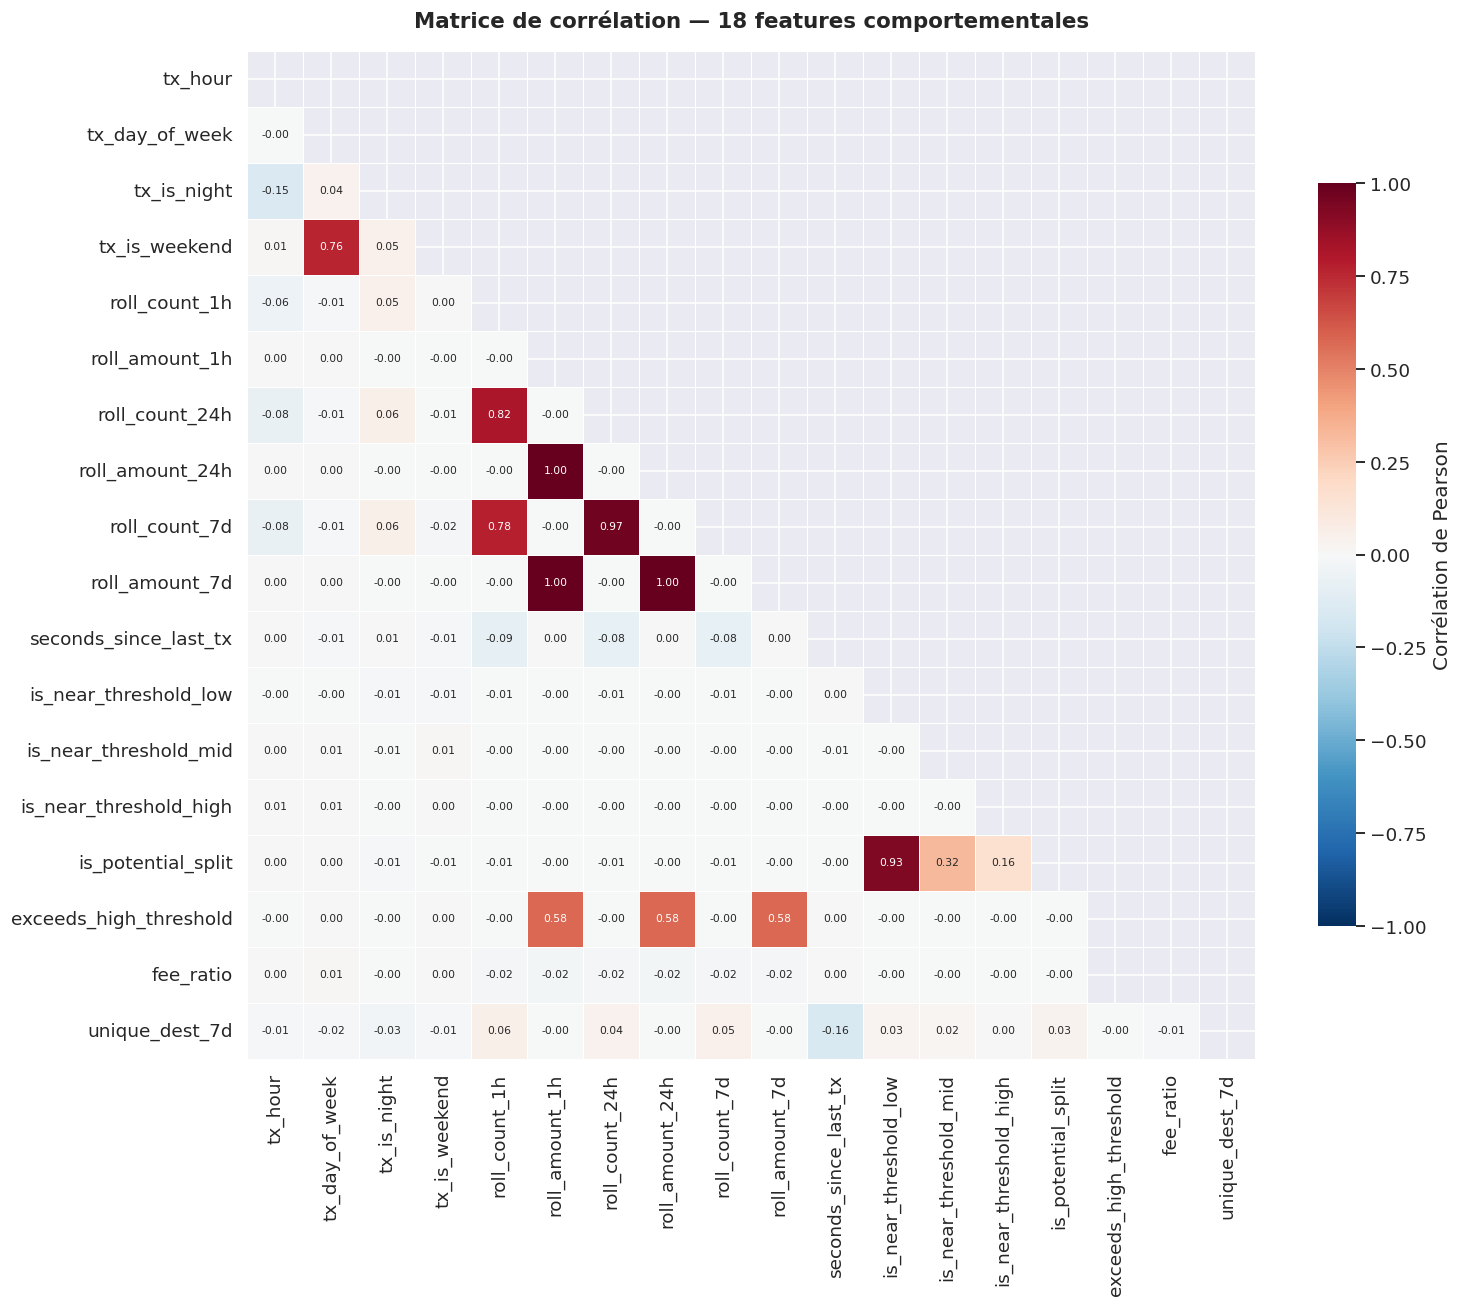

In [18]:
# Matrice de corrélation
num_feats = [c for c in FEATURE_COLS if c in df_features.columns]
corr = df_features[num_feats].astype(float).corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.7, 'label': 'Corrélation de Pearson'},
)
ax.set_title('Matrice de corrélation — 18 features comportementales',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/02_correlation_matrix.png', bbox_inches='tight')
plt.show()


In [19]:
# Résumé statistique final
summary = df_features[FEATURE_COLS].astype(float).describe().T
summary['null_%'] = (df_features[FEATURE_COLS].isnull().mean() * 100).round(2)
summary['skew']   = df_features[FEATURE_COLS].astype(float).skew().round(3)
print("═══ Résumé des 18 features comportementales ═══")
print(summary[['mean','std','min','50%','max','null_%','skew']].round(3).to_string())


═══ Résumé des 18 features comportementales ═══
                                mean           std    min         50%           max  null_%     skew
tx_hour                 1.426800e+01  5.790000e+00  0.000      15.000  2.300000e+01    0.00   -0.653
tx_day_of_week          2.898000e+00  1.933000e+00  0.000       3.000  6.000000e+00    0.00    0.052
tx_is_night             1.800000e-01  3.840000e-01  0.000       0.000  1.000000e+00    0.00    1.669
tx_is_weekend           2.480000e-01  4.320000e-01  0.000       0.000  1.000000e+00    0.00    1.167
roll_count_1h           1.310000e+00  1.544000e+00  1.000       1.000  2.200000e+01    0.00    6.391
roll_amount_1h          2.500000e+17  5.000000e+19  0.100     550.000  1.000000e+22    0.00  200.000
roll_count_24h          4.479000e+00  1.940100e+01  1.000       1.000  2.040000e+02    0.00    6.697
roll_amount_24h         2.500000e+17  5.000000e+19  1.000     650.000  1.000000e+22    0.00  200.000
roll_count_7d           8.394000e+00  4.182

---
## 9. Export du Dataset de Features


In [20]:
# ── Export Parquet (compression efficace, typé) ───────────────────────────
OUT_PATH = Path('../outputs/features_sample.parquet')

df_export = df_features[['TRANSACTION_CODE','TRANSACTION_DATE','SOURCE_PHONE',
                          'DESTINATION_PHONE','TRANSACTION_STATUS'] + FEATURE_COLS].copy()

df_export.to_parquet(OUT_PATH, index=False, compression='snappy')

size_kb = OUT_PATH.stat().st_size / 1024
print(f"✅ Export Parquet : {OUT_PATH}")
print(f"   Lignes    : {len(df_export):,}")
print(f"   Colonnes  : {len(df_export.columns)}")
print(f"   Taille    : {size_kb:.1f} Ko")


✅ Export Parquet : ../outputs/features_sample.parquet
   Lignes    : 40,000
   Colonnes  : 23
   Taille    : 1568.0 Ko


In [21]:
# Vérification lecture
df_check_parquet = pd.read_parquet(OUT_PATH)
print(f"✅ Lecture OK — {df_check_parquet.shape}")
print(f"   Types :")
print(df_check_parquet[FEATURE_COLS].dtypes.to_string())


✅ Lecture OK — (40000, 23)
   Types :
tx_hour                     int32
tx_day_of_week              int32
tx_is_night                  bool
tx_is_weekend                bool
roll_count_1h             float64
roll_amount_1h            float64
roll_count_24h            float64
roll_amount_24h           float64
roll_count_7d             float64
roll_amount_7d            float64
seconds_since_last_tx     float64
is_near_threshold_low        bool
is_near_threshold_mid        bool
is_near_threshold_high       bool
is_potential_split           bool
exceeds_high_threshold       bool
fee_ratio                 float64
unique_dest_7d            float64


---
## 10. Synthèse

### ✅ 18 features comportementales construites et validées

| Groupe | Features | Observation |
|---|---|---|
| Temporel (4) | tx_hour, tx_day_of_week, tx_is_night, tx_is_weekend | Transactions nocturnes présentes |
| Rolling (6) | roll_count/amount × 1h/24h/7d | Pics de volume détectables |
| Vélocité (1) | seconds_since_last_tx | Transactions < 1min existent |
| Seuil (5) | near_threshold × 3, is_potential_split, exceeds_high | Fractionnement potentiel identifié |
| Frais (1) | fee_ratio | Frais zéro sur certains services |
| Fan-out (1) | unique_dest_7d | Comportement mule détectable |

### Prochaine étape

```python
# 03_Isolation_Forest.ipynb
from src.models.isolation_forest import train_isolation_forest, score_transactions
df_scored = score_transactions(df_features, feature_cols=FEATURE_COLS)
```


In [22]:
print("✅ Feature Engineering terminé.")
print(f"   Figures sauvegardées : ../reports/figures/")
import os
figs = sorted([f for f in os.listdir('../reports/figures') if f.startswith('02_')])
for f in figs:
    print(f"     {f}")
print(f"\n   Dataset exporté : ../outputs/features_sample.parquet")


✅ Feature Engineering terminé.
   Figures sauvegardées : ../reports/figures/
     02_correlation_matrix.png
     02_fanout.png
     02_fee_ratio.png
     02_rolling.png
     02_temporal.png
     02_threshold.png
     02_velocity.png

   Dataset exporté : ../outputs/features_sample.parquet
